# Apache Spark Kaggle Competition Notebook

This notebook goes through the steps used to submit to kaggle house prices competition found at https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data



#1. Data Download and Inspection

In [ ]:
#Library Imports
import os
import time
import json
import glob
import shutil
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, log, exp, monotonically_increasing_id
from pyspark.sql.functions import sum as spark_sum
from pyspark.sql.types import IntegerType, DoubleType, FloatType, LongType
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler,
    StandardScaler, UnivariateFeatureSelector
)
from pyspark.ml.regression import (
    LinearRegression, DecisionTreeRegressor,
    RandomForestRegressor, GBTRegressor
)
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline
from google.colab import files

In [ ]:
#Replace with credentials (Note: The user must be entered into the competition to be able to download the data)
#The competition can be found at https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_creds = {
    "username": "",
    "key": ""
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

#kaggle requires the file to be owner readable
os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [ ]:
#Install Kaggle package if not allready installed
!pip install kaggle

In [ ]:
#Confirm we have authenticated and our details work
!kaggle competitions list

ref                                                                              deadline             category          reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  ---------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3    2026-04-15 23:59:00  Featured   2,207,152 Usd       3144           False  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured   1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured   1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured   1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detec

In [ ]:
#Download and unzip the 'House Prices - Advanced Regression Techniques' data
#A txt file containing descriptions of each field is also downloaded as part of the competition
!kaggle competitions download house-prices-advanced-regression-techniques
!unzip house-prices-advanced-regression-techniques.zip

usage: kaggle competitions [-h]
                           {list,files,download,submit,submissions,leaderboard}
                           ...
kaggle competitions: error: argument command: invalid choice: 'join' (choose from list, files, download, submit, submissions, leaderboard)
house-prices-advanced-regression-techniques.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  house-prices-advanced-regression-techniques.zip
replace data_description.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

When setting up our spark isntance, we set the 'shuffle partitions' field to be twice the number of CPU cores in this instance. This was done after inital slow training times. Upon research, I found that Sparks default value (200) is larger than necessary for our size of dataset and can cause overhead in training. By reducing this to better match our task, this provides a noticable improvment in training times. 2x the CPU cores was selected as this seemed to be the recommended approach based on research.

In [ ]:
cores = os.cpu_count() or 2 #get cpu core count

#Create a Spark Session
spark = SparkSession.builder \
        .appName('PBD Apache Spark Assignment') \
        .master('local[*]') \
        .config("spark.sql.shuffle.partitions", cores * 2) \
        .getOrCreate()

In [ ]:
# Load the training and testing data
data = spark.read.csv("train.csv", header=True, inferSchema=True)
data.show(5)

+---+----------+--------+-----------+-------+------+-----+--------+-----------+---------+---------+---------+------------+----------+----------+--------+----------+-----------+-----------+---------+------------+---------+--------+-----------+-----------+----------+----------+---------+---------+----------+--------+--------+------------+------------+----------+------------+----------+---------+-----------+-------+---------+----------+----------+--------+--------+------------+---------+------------+------------+--------+--------+------------+------------+-----------+------------+----------+----------+-----------+----------+-----------+------------+----------+----------+----------+----------+----------+----------+-----------+-------------+---------+-----------+--------+------+-----+-----------+-------+------+------+--------+-------------+---------+
| Id|MSSubClass|MSZoning|LotFrontage|LotArea|Street|Alley|LotShape|LandContour|Utilities|LotConfig|LandSlope|Neighborhood|Condition1|Condition

In [ ]:
#Check if we have any NULLs
print("Null counts per column:")
null_cols = []
for c in data.columns:
    count = data.filter(col(c).isNull()).count()
    if count > 0:
        null_cols.append(f"  {c}: {count}")

if null_cols:
    for line in null_cols:
        print(line)
else:
    print("  No null values found")

Null counts per column:
  No null values found


From the above, we can see that certain columns contain NA values. It is good to get an idea for what columns contain these NA values before we decide how to handle them.

In [ ]:
print("Columns with 'NA' string values:")
for column in data.columns:
    na_count = data.filter(col(column).cast("string") == "NA").count()
    if na_count > 0:
        print(f"  {column}: {na_count} 'NA' values")

Columns with 'NA' string values:
  LotFrontage: 259 'NA' values
  Alley: 1369 'NA' values
  MasVnrType: 8 'NA' values
  MasVnrArea: 8 'NA' values
  BsmtQual: 37 'NA' values
  BsmtCond: 37 'NA' values
  BsmtExposure: 38 'NA' values
  BsmtFinType1: 37 'NA' values
  BsmtFinType2: 38 'NA' values
  Electrical: 1 'NA' values
  FireplaceQu: 690 'NA' values
  GarageType: 81 'NA' values
  GarageYrBlt: 81 'NA' values
  GarageFinish: 81 'NA' values
  GarageQual: 81 'NA' values
  GarageCond: 81 'NA' values
  PoolQC: 1453 'NA' values
  Fence: 1179 'NA' values
  MiscFeature: 1406 'NA' values


For many of these columns, NA is a legitimate value and thus we will keep it as such.

For a couple of columns in particular (LotFrontage, MasVnrArea), I feel these would be better represented as continuous fields rather than strings. I found this out later in the pipline as I had put them in my continuous variables list when they had been (rightly) infered as strings.

To solve this, I will cast these fields to numbers and convert any NA values to 0 (represnting they have no lot frontage/masvnr area)

I tried using try_cast but it is not available in this Spark version so had to use a more explicit approach

In [ ]:
cast_cols = [
    "LotFrontage", "MasVnrArea"
]
for c in cast_cols:
    data = data.withColumn(
        c,
        when(col(c).cast("string") == "NA", 0).otherwise(col(c)).cast("double")
    )

In [ ]:
# Explore the data
print(f"Total rows: {data.count()}")
print(f"Total columns: {len(data.columns)}")

print("\nTarget Variable Distribution:")
data.groupBy("SalePrice").count().orderBy(col("count").desc()).show()

Total rows: 1460
Total columns: 81

Target Variable Distribution:
+---------+-----+
|SalePrice|count|
+---------+-----+
|   140000|   20|
|   135000|   17|
|   145000|   14|
|   155000|   14|
|   110000|   13|
|   190000|   13|
|   160000|   12|
|   115000|   12|
|   130000|   11|
|   139000|   11|
|   143000|   10|
|   144000|   10|
|   180000|   10|
|   185000|   10|
|   125000|   10|
|   147000|    9|
|   100000|    9|
|   127000|    9|
|   175000|    9|
|   141000|    8|
+---------+-----+
only showing top 20 rows


We can see that our dataset contains no missing/Null values and so we are ok to conitnue. We will however drop the 'Id' column at this point as it is uncesseary for this analysis.

In [ ]:
data = data.drop('Id')

Next, we will split our data into testing and training data using pysparks random split

In [ ]:
# Train/test split - done here after cleaning but before any feature engineering
training_data, testing_data = data.randomSplit([0.8, 0.2], seed=42)

Now, we will look at the distribution of our target variable 'Sales Price'

In [ ]:
training_data.select('SalePrice').describe().show()

+-------+-----------------+
|summary|        SalePrice|
+-------+-----------------+
|  count|             1207|
|   mean|180052.0530240265|
| stddev|78025.66140412452|
|    min|            35311|
|    max|           755000|
+-------+-----------------+



We notice that the default 'show' function in Spark does not include quartiles. We would ideally like to see these so we must create a seperate function to give us the quartiles.

In [ ]:
#View the target variable Percentiles

#Calculate our quartiles using the approxQuantile function
# rather than sorting the entire dataset,
#it uses the Greenwald-Khanna algorithm to estimate the quantiles within a relative error bound.
#The final param '0.01' means we want a result to be accurate wihtin 1% of true quartiles

quantiles = training_data.approxQuantile(
    "SalePrice",
    [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95],
    0.01
)

#Print our quartile values
labels = ["5th", "10th", "25th", "50th", "75th", "90th", "95th"]
for label, val in zip(labels, quantiles):
    print(f"{label} percentile: {val:,.0f}")

5th percentile: 87,000
10th percentile: 107,500
25th percentile: 130,000
50th percentile: 161,750
75th percentile: 212,000
90th percentile: 269,500
95th percentile: 315,000


We will now check for any ouliers in our continuous columns

In [ ]:
#We will not include GarageYrBlt in our outlier analysis as an outlier as an outlier for
#this field simply indicates a garage is old and is useful for our analysis to keep in

continuous_cols = [
    "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
    "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
    "GrLivArea", "GarageArea","WoodDeckSF", "OpenPorchSF",
    "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
    "SalePrice"
]

total_rows = training_data.count()

print(f"{'Column':<20} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lower':>10} {'Upper':>10} {'Outliers':>10} {'%':>8}")
print("-" * 98)


for col_name in continuous_cols:
   #Use PySpark's ApproxQuartile funcion to get approximate quartiles
   #0.01 indicates we want our quartiles to be within 1% difference
   #from the true quartiles
    q1, q3 = training_data.approxQuantile(col_name, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = training_data.filter(
        (col(col_name) < lower) | (col(col_name) > upper)
    ).count()

    pct = (outlier_count / total_rows) * 100

    print(f"{col_name:<20} {q1:>10,.1f} {q3:>10,.1f} {iqr:>10,.1f} {lower:>10,.1f} {upper:>10,.1f} {outlier_count:>10} {pct:>7.1f}%")

Column                       Q1         Q3        IQR      Lower      Upper   Outliers        %
--------------------------------------------------------------------------------------------------
LotFrontage                43.0       78.0       35.0       -9.5      130.5         16     1.3%
LotArea                 7,642.0   11,512.0    3,870.0    1,837.0   17,317.0         78     6.5%
MasVnrArea                  0.0      148.0      148.0     -222.0      370.0         90     7.5%
BsmtFinSF1                  0.0      697.0      697.0   -1,045.5    1,742.5          7     0.6%
BsmtFinSF2                  0.0        0.0        0.0        0.0        0.0        148    12.3%
BsmtUnfSF                 230.0      797.0      567.0     -620.5    1,647.5         28     2.3%
TotalBsmtSF               796.0    1,284.0      488.0       64.0    2,016.0         58     4.8%
1stFlrSF                  892.0    1,382.0      490.0      157.0    2,117.0         21     1.7%
2ndFlrSF                    0.0      

For this particular dataset, the reported outliers represent meaningful values. A house with a large GrLivArea or high SalePrice isn't a data error and simply represents a big/expensive house. Capping those would suppress real singals that the model can later use. The same goes for many of the other continuous values. For this reason we will be keeping the ouliers in (but may revisit this later if it is found to improve model performance).

#2. Setting Up Preprocessing Pipeline

##2.1. Categorical Fields

For Categorical fields, we will use pySparks StringIndexer to convert our string fields to numeric indeces based on frequency. This is a necessary step as Spark's OneHotEncoder only accepts numeric input and cannot work direcly on strings

In [ ]:
#Select our categorical
categorical_features = [
    "MSZoning", "Street", "Alley", "LandContour", "LotConfig",
    "Neighborhood", "Condition1", "Condition2", "BldgType",
    "HouseStyle", "RoofStyle", "RoofMatl", "Exterior1st",
    "Exterior2nd", "MasVnrType", "Foundation", "Heating",
    "GarageType", "MiscFeature", "SaleType", "SaleCondition"
]

#Use String Indexer on categocical columns to numeric incides
cat_indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_features
]

cat_indexed_cols = [f"{c}_idx" for c in categorical_features]
cat_encoded_cols = [f"{c}_ohe" for c in categorical_features]

#Use OneHot Encoder for categorical variables
cat_encoder = OneHotEncoder(
    inputCols=cat_indexed_cols,
    outputCols=cat_encoded_cols,
    handleInvalid="keep"
)

##2.2. Ordinal Fields

For ordinal fields, we want to maintain the  natural order of the values within the fields. one-hot encoding would lose this information as it does not account for this natural order. In order to maintain order, we will map each value to a numeric value that preserves the order of the fields.

Unfortunately, as this is not a pipeline compatible stage, we must performt his operation manually.

In [ ]:
def encode_ordinal(df):

  # Some fields use the same quality scale, so we encode these fields first
  quality_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond",
                  "HeatingQC", "KitchenQual", "FireplaceQu",
                  "GarageQual", "GarageCond", "PoolQC"]

  for c in quality_cols:
      df = df.withColumn(c + "_enc",
          when(col(c) == "Po", 1)
          .when(col(c) == "Fa", 2)
          .when(col(c) == "TA", 3)
          .when(col(c) == "Gd", 4)
          .when(col(c) == "Ex", 5)
          .otherwise(0)  # NA = no feature present
      )


  #PoolQC: Fa=1, TA=2, Gd=3, Ex=4 (no Po category)
  df = df.withColumn("PoolQC_enc",
      when(col("PoolQC") == "Fa", 1)
      .when(col("PoolQC") == "TA", 2)
      .when(col("PoolQC") == "Gd", 3)
      .when(col("PoolQC") == "Ex", 4)
      .otherwise(0))

  #BsmtExposure: No=1, Mn=2, Av=3, Gd=4
  df = df.withColumn("BsmtExposure_enc",
      when(col("BsmtExposure") == "No", 1)
      .when(col("BsmtExposure") == "Mn", 2)
      .when(col("BsmtExposure") == "Av", 3)
      .when(col("BsmtExposure") == "Gd", 4)
      .otherwise(0))

  #BsmtFinType: Unf=1, LwQ=2, Rec=3, BLQ=4, ALQ=5, GLQ=6
  for c in ["BsmtFinType1", "BsmtFinType2"]:
      df = df.withColumn(c + "_enc",
          when(col(c) == "Unf", 1)
          .when(col(c) == "LwQ", 2)
          .when(col(c) == "Rec", 3)
          .when(col(c) == "BLQ", 4)
          .when(col(c) == "ALQ", 5)
          .when(col(c) == "GLQ", 6)
          .otherwise(0))

  #Functional: Sal=1, Sev=2, Maj2=3, Maj1=4, Mod=5, Min2=6, Min1=7, Typ=8
  df = df.withColumn("Functional_enc",
      when(col("Functional") == "Sal", 1)
      .when(col("Functional") == "Sev", 2)
      .when(col("Functional") == "Maj2", 3)
      .when(col("Functional") == "Maj1", 4)
      .when(col("Functional") == "Mod", 5)
      .when(col("Functional") == "Min2", 6)
      .when(col("Functional") == "Min1", 7)
      .when(col("Functional") == "Typ", 8)
      .otherwise(0))

  #GarageFinish: Unf=1, RFn=2, Fin=3
  df = df.withColumn("GarageFinish_enc",
      when(col("GarageFinish") == "Unf", 1)
      .when(col("GarageFinish") == "RFn", 2)
      .when(col("GarageFinish") == "Fin", 3)
      .otherwise(0))

  #Fence: MnWw=1, GdWo=2, MnPrv=3, GdPrv=4
  df = df.withColumn("Fence_enc",
      when(col("Fence") == "MnWw", 1)
      .when(col("Fence") == "GdWo", 2)
      .when(col("Fence") == "MnPrv", 3)
      .when(col("Fence") == "GdPrv", 4)
      .otherwise(0))

  #LandSlope: Gtl=1, Mod=2, Sev=3
  df = df.withColumn("LandSlope_enc",
      when(col("LandSlope") == "Gtl", 1)
      .when(col("LandSlope") == "Mod", 2)
      .when(col("LandSlope") == "Sev", 3)
      .otherwise(0))

  #LotShape: IR3=1, IR2=2, IR1=3, Reg=4
  df = df.withColumn("LotShape_enc",
      when(col("LotShape") == "IR3", 1)
      .when(col("LotShape") == "IR2", 2)
      .when(col("LotShape") == "IR1", 3)
      .when(col("LotShape") == "Reg", 4)
      .otherwise(0))

  #Utilities: ELO=1, NoSeWa=2, NoSewr=3, AllPub=4
  df = df.withColumn("Utilities_enc",
      when(col("Utilities") == "ELO", 1)
      .when(col("Utilities") == "NoSeWa", 2)
      .when(col("Utilities") == "NoSewr", 3)
      .when(col("Utilities") == "AllPub", 4)
      .otherwise(0))

  #Electrical: Mix=1, FuseP=2, FuseF=3, FuseA=4, SBrkr=5
  df = df.withColumn("Electrical_enc",
      when(col("Electrical") == "Mix", 1)
      .when(col("Electrical") == "FuseP", 2)
      .when(col("Electrical") == "FuseF", 3)
      .when(col("Electrical") == "FuseA", 4)
      .when(col("Electrical") == "SBrkr", 5)
      .otherwise(0))

  #PavedDrive: N=1, P=2, Y=3
  df = df.withColumn("PavedDrive_enc",
      when(col("PavedDrive") == "N", 1)
      .when(col("PavedDrive") == "P", 2)
      .when(col("PavedDrive") == "Y", 3)
      .otherwise(0))

  #CentralAir: N=0, Y=1
  df = df.withColumn("CentralAir_enc",
      when(col("CentralAir") == "Y", 1)
      .otherwise(0))
  return df

In [ ]:
training_data = encode_ordinal(training_data)
testing_data = encode_ordinal(testing_data)

I found that training times were slower than I expected and ,upon research, found that by caching the training data, training speeds are improved. I found that unlike the likes of scikit-learn which executes transformations immediately, Spark is lazy as it builds up a deferred execution plan and only runs it when an action like .fit() is triggered. Without caching, this means Spark would re-execute the full transformation chain (CSV read, casting, ordinal encoding, split) from scratch on every one of the cross-validation fold fits, so caching the fully-prepared training data ensures it is computed once and held in memory for all subsequent folds. Doing this provided a noticable increase in training times

In [ ]:
training_data.cache() #Cache the training data
training_data.count()  # materialise the cache immediately

1207

##2.3. Final Encoding Stages Definition

The encoding pipeline runs in four stages. First, our previouly defined categorical encoder hanldes the categorical columns. Next, a VectorAssembler combines all 56 numerical columns — continuous measurements, discrete counts, and the manually ordinal-encoded fields — into a single vector called num_features. Finally, a second VectorAssembler merges this numerical vector with the 21 one-hot encoded vectors into a single features column, which is the format required by Spark MLlib models.

In [ ]:
continuous_cols = [
    "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
    "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
    "GrLivArea", "GarageArea", "WoodDeckSF", "OpenPorchSF",
    "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal"
]

discrete_cols = [
    "OverallQual", "OverallCond", "YearBuilt", "YearRemodAdd",
    "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath",
    "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces",
    "GarageCars", "MoSold", "YrSold"
]

ordinal_encoded_cols = [
    "ExterQual_enc", "ExterCond_enc", "BsmtQual_enc", "BsmtCond_enc",
    "HeatingQC_enc", "KitchenQual_enc", "FireplaceQu_enc",
    "GarageQual_enc", "GarageCond_enc", "PoolQC_enc",
    "BsmtExposure_enc", "BsmtFinType1_enc", "BsmtFinType2_enc",
    "Functional_enc", "GarageFinish_enc", "Fence_enc",
    "LandSlope_enc", "LotShape_enc", "Utilities_enc",
    "Electrical_enc", "PavedDrive_enc", "CentralAir_enc"
]

#We combine our continusous cols with our discrete numerical cols
# Ordinals are already numeric so they join numerical features
numerical_features = continuous_cols + discrete_cols + ordinal_encoded_cols

#Assemble numeric vector
num_assembler = VectorAssembler(
    inputCols=numerical_features,
    outputCol="num_features",
    handleInvalid="skip"
)

#Combine all features together
final_assembler = VectorAssembler(
    inputCols=["num_features"] + cat_encoded_cols,
    outputCol="features",
    handleInvalid="skip"
)

#Define pre-processing stages
encoding_stages = cat_indexers + [cat_encoder, num_assembler, final_assembler]

#3. Feature Selection and Final Preprocessing Pipeline Assembly

We will not define our final preprocessing steps and create our full preprocessing pipeline.





##3.1. Feature selection

As this dataset contains a large number of columns, some of which may have little to no predictive relationshitp with the target variable. To remove these features, we will use feature selection as part of our pipeline. In this case, we will be using Spark's UnivariateFeatureSelector feature selector which uses the top N features based on an F-regression Test (which measure linear correlation with the target). After running training with mutliple max features, 50 was found to return the best results


In [ ]:
feature_selector = UnivariateFeatureSelector(
    featuresCol="features",
    outputCol="selected_features",
    labelCol="SalePrice",
    selectionMode="numTopFeatures"
)
feature_selector.setFeatureType("continuous")
feature_selector.setLabelType("continuous")
# top 50  (found to produce best results)
feature_selector.setSelectionThreshold(50)

UnivariateFeatureSelector_1bbf29b71a6f

##3.2. Scaling (Linear Regression Only)

As we will be testing Linear Regression as one of our models, we will also define a scaler to prevent overfitting and normalise our values.

In [ ]:
# Scaler for linear regression (applied after feature selection)
scaler = StandardScaler(
    inputCol="selected_features",
    outputCol="scaled_features",
    withStd=True,
    withMean=True
)

##3.3. Final Pipeline Creation


To further improve training speed, we pre-compute the full feature pipeline once rather than re-running it on every cross-validation fold. The preprocessing pipeline (StringIndexer, OneHotEncoder, VectorAssembler, FeatureSelector) is fitted on the training data and used to transform both training and test sets upfront. The resulting DataFrame is then cached in memory. This means each CV fold only needs to fit and evaluate the model itself rather then repeated for each fold. Originally, I had the 'selectionThreshold' as part of the tuning grid, but found that this significanlty imcreased training times. The `selectionThreshold` is fixed at 50 as a results (50 was selected based on initial results when it was in the tuning grid), which is an acceptable tradeoff given the speed improvement. This is similar to how we cached our training data earlier due to Spark's lazy approach.

In [ ]:
# Build a preprocessing-only pipeline (no model stage)
# This includes all encoding, assembly, feature selection
# The scaler is excluded here as it should fit per-fold for LR correctness
preprocessing_pipeline = Pipeline(
    stages=encoding_stages + [feature_selector]
)

# Fit on training data only, then transform both sets
preprocessing_model = preprocessing_pipeline.fit(training_data)
train_features = preprocessing_model.transform(training_data)
test_features  = preprocessing_model.transform(testing_data)

# Cache train_features
train_features.cache()
train_features.count()  # materialise the cache

1207

#4. Model Definitions and Parameter Grids

We will be testing 4 models from the Spark regression library.



1.   Linear Regression
2.   Decision Tree
3.   Random Forest
4.   Gradient Boosted Decision Tree (GBT)

We will be using Spark's grid search ability (ParamGridBuilder) to define a grid of hyperparamter combinations to try for each model. Each grid combination will be evaluated using Spark's regression evaluator with crossvalidation (CrossValidator). This should provide us with the optimal combination of features and hyperparamters that will give us the best RMSE (the competition's evaluation metric)



In [ ]:
#Define our Regression Evaluator
#Defiing SalePrice as our target field
evaluator = RegressionEvaluator(
    labelCol="SalePrice",
    predictionCol="prediction",
    metricName="rmse"
)

##4.1. Linear Regression

We will define our initial grid params (these are subject to change based on results)

In [ ]:
#Linear Regression (uses scaled + selected features)
lr = LinearRegression(
    featuresCol="scaled_features",
    labelCol = "SalePrice")

#LR still needs scaling, so we wrap scaler+lr in a small pipeline as the CV estimator
lr_pipeline = Pipeline(stages=[scaler, lr])

#Define our grid to search
lr_grid = (ParamGridBuilder()
    #RegulariRation strength (higher = simpler model, more penalty)
    .addGrid(lr.regParam, [0.01, 0.1, 0.5])
    # Balance between L1 (Lasso) and L2 (Ridge)
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
    .build())

#Define our CrossValidator
lr_cv = CrossValidator(
    estimator=lr_pipeline, #Full Pipeline to Evaluate
    estimatorParamMaps=lr_grid, # 27 param combos
    evaluator=evaluator, # use RMSE for evaluations
    numFolds=5, # splits training data into 5 folds,
    #Set parallelism to allow for folds to be run
    #concurrently, speading up training time (as default is one which
    #meand folds are run sequentially)
    #We set to number of cores to best utilise.
    parallelism = cores,
    seed=42 #Set for reproducibility
)

##4.2. Decision Tree

We will define our initial grid params (these are subject to change based on results)

In [ ]:
#Decision Tree Regressor (Uses selected Features + no scaling)
dt = DecisionTreeRegressor(
    featuresCol="selected_features",
    labelCol="SalePrice"
)

dt_grid = (ParamGridBuilder()
    # maxDepth: how many levels deep the tree can grow
    # Deeper = more complex, risks overfitting
    # Shallower = simpler, risks underfitting
    .addGrid(dt.maxDepth, [5, 10, 15])
    # minInstancesPerNode: minimum rows required at each leaf
    # Higher values prevent the tree from learning very specific rules
    .addGrid(dt.minInstancesPerNode, [2, 5, 10])
    .build()
)

#Define our CrossValidator (same steps as Lineare Regresssion but with DT grid)
dt_cv = CrossValidator(
    estimator=dt, # just the model - features already assembled
    estimatorParamMaps=dt_grid,
    evaluator=evaluator,
    numFolds=5,
    parallelism = cores,
    seed=42
)

##4.3. Random Forest

We will define our initial grid params (these are subject to change based on results)

In [ ]:
#Random forest Regressor (uses selected features, no scaling)
rf = RandomForestRegressor(
    featuresCol="selected_features",
    labelCol="SalePrice"
)


rf_grid = (ParamGridBuilder()
    # numTrees: how many trees in the forest
    # More trees = more stable predictions but slower training
    .addGrid(rf.numTrees, [50, 100, 200])
    # maxDepth: depth limit for each individual tree
    .addGrid(rf.maxDepth, [5, 10, 15])
    .build()
)

rf_cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=rf_grid,
    evaluator=evaluator,
    numFolds=5,
    parallelism = cores,
    seed=42
)

##4.4. GBT

GBT builds trees sequentially — each new tree focuses on correcting the errors of the previous ones, gradually improving predictions

I initally had hoped to test more features but due to extensive training times, reduced the number of combinations to ensure realistic training times.

In [ ]:
gbt = GBTRegressor(
    featuresCol="selected_features",
    labelCol="SalePrice"
)


gbt_grid = (ParamGridBuilder()
    # maxIter: number of boosting rounds (trees built sequentially)
    # More iterations = better fit but risk of overfitting
    .addGrid(gbt.maxIter, [50, 100])
    # maxDepth: depth of each individual tree
    .addGrid(gbt.maxDepth, [3, 5])
    # stepSize (learning rate): how much each new tree contributes
    # Smaller = more conservative, needs more iterations but generalises better
    # Larger = learns faster but can overshoot
    .addGrid(gbt.stepSize, [0.01,0.05])
    .build()
)

gbt_cv = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=gbt_grid,
    evaluator=evaluator,
    numFolds=3,
    parallelism = cores,
    seed=42
)

#5. Model Training and Evaluation

Now that we have all of our models and their grids defined, we will train and
evaluate each model to determine a) the best model to use for our submission annd b) the best hyperparamters to use for said model

Some Notes on the training developmenet process:

1. Originally, training was happening very slowly (more than I had expected). Upon research, I found a big improvment by setting the 'Parrallilism' variable in my cross validator. By default, Spark evaluates each fold sequentially. Adding parallelism tells it to evaluate multiple folds at the same time. For Colab which runs on a single machine with local[*], this made an improvement to the training speeds.

2. Another speed improvment was from caching my training data as mentioned previously.

3. Finally, setting the shuffle partition to 2*cores as preivously mentinoed improved training speeds.


In [ ]:
#Define our Regression Evaluators (we will also look at r2 and mae for completeness sake)
evaluator_r2 = RegressionEvaluator(
    labelCol="SalePrice", predictionCol="prediction", metricName="r2"
)
evaluator_mae = RegressionEvaluator(
    labelCol="SalePrice", predictionCol="prediction", metricName="mae"
)

In [ ]:
#Our list of models to train
models = {
    "Linear Regression": lr_cv,
    "Decision Tree":     dt_cv,
    "Random Forest":     rf_cv,
    "GBT":               gbt_cv
}

results = []
best_models = {}

for name, cv in models.items():
    print(f"\nTraining {name} with {cv.getNumFolds()}-fold CV...")

    #Start a timer and fit our training data
    start_time = time.time()
    cv_model = cv.fit(train_features)
    elapsed = time.time() - start_time
    #store our best model
    best_pipeline_model = cv_model.bestModel
    best_params = cv_model.getEstimatorParamMaps()[
        cv_model.avgMetrics.index(__builtins__.min(cv_model.avgMetrics))
    ]

    print(f"\n  Best hyperparameters:")
    for param, value in best_params.items():
        print(f"    {param.name}: {value}")

    #Evaluate on test set
    predictions = cv_model.transform(test_features)

    #evalueate the model predictions
    rmse = evaluator.evaluate(predictions)
    r2   = evaluator_r2.evaluate(predictions)
    mae  = evaluator_mae.evaluate(predictions)
    best_cv_rmse = __builtins__.min(cv_model.avgMetrics)

    results.append((name, rmse, r2, mae, best_cv_rmse, elapsed))
    best_models[name] = cv_model

    #output our results
    print(f"\n  Results:")
    print(f"Best CV RMSE: {best_cv_rmse:.4f}")
    print(f"Test RMSE:    {rmse:.4f}")
    print(f"Test R²:      {r2:.4f}")
    print(f"Test MAE:     {mae:.4f}")


print(f"\n{'Model':<25} {'CV RMSE':>10} {'Test RMSE':>10} {'R²':>10} {'MAE':>10} {'Time(s)':>10}")
print("-" * 78)
for name, rmse, r2, mae, cv_rmse, elapsed in sorted(results, key=lambda x: x[1]):
    print(f"{name:<25} {cv_rmse:>10.4f} {rmse:>10.4f} {r2:>10.4f} {mae:>10.4f} {elapsed:>10.1f}")

best = __builtins__.min(results, key=lambda x: x[1])
print(f"\nBest model: {best[0]} (Test RMSE: {best[1]:.4f})")


Training Linear Regression with 5-fold CV...

  Best hyperparameters:
    regParam: 0.5
    elasticNetParam: 1.0

  Results:
Best CV RMSE: 34394.7032
Test RMSE:    33768.0994
Test R²:      0.8449
Test MAE:     22646.5642

Training Decision Tree with 5-fold CV...

  Best hyperparameters:
    maxDepth: 15
    minInstancesPerNode: 10

  Results:
Best CV RMSE: 39611.5180
Test RMSE:    36291.3252
Test R²:      0.8209
Test MAE:     24565.2761

Training Random Forest with 5-fold CV...

  Best hyperparameters:
    numTrees: 200
    maxDepth: 15

  Results:
Best CV RMSE: 29633.3637
Test RMSE:    27468.5848
Test R²:      0.8974
Test MAE:     17093.2638

Training GBT with 3-fold CV...

  Best hyperparameters:
    maxIter: 100
    maxDepth: 3
    stepSize: 0.05

  Results:
Best CV RMSE: 36638.2202
Test RMSE:    33715.7685
Test R²:      0.8454
Test MAE:     22336.2570

Model                        CV RMSE  Test RMSE         R²        MAE    Time(s)
-------------------------------------------------

#6. Training Results Analysis

Random Forest was the clear best performer, achieving a Test RMSE of 27,468 and an R² of 0.89, meaning it explains approximately 89% of the variance in house sale prices. Its CV RMSE of 29,633 was also the lowest across all models, indicating the result is reliable and not simply a product of a favourable test split. The optimal Random Forest configuration used 200 trees with a maximum depth of 15. Linear Regression and GBT performed comparably, both achieving a Test RMSE of approximately 33,700–33,800 and R² of 0.84, though Linear Regression trained in just 59 seconds compared to GBT's 664 seconds which is a significant efficiency advantage for similar performance. Decision Tree was the weakest model with a Test RMSE of 39,611, which is expected given it is a single tree without the variance reduction benefits of ensemble methods. Based on these results, Random Forest was selected as the final model for the Kaggle submission. It is worth noting that GBT's underperformance relative to Random Forest is likely attributable to the constrained parameter grid used to manage training time and could have possily been tuned to be more competitive.

#7. Submitting our Competition Entry


Finally, now that we have identified our best model, let's run it against the test file and see what our competition results are like!

#7.1. Running Our Best Model on Competition Data

First, we must open and process our test data in the same way as was done to the rest of our data.

In [ ]:
# Load test data
submission_data = spark.read.csv("test.csv", header=True, inferSchema=True)

# Extended cast list - test.csv has more NA-as-string columns than train.csv
submission_cast_cols = cast_cols + [
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "GarageArea", "BsmtFullBath", "BsmtHalfBath", "GarageCars"
]

for c in submission_cast_cols:
    submission_data = submission_data.withColumn(
        c, when(col(c) == "NA", 0).otherwise(col(c)).cast("double")
    )

# Save Id before dropping
submission_ids = submission_data.select("Id")
submission_data = submission_data.drop("Id")

# Apply ordinal encoding and preprocessing
submission_data = encode_ordinal(submission_data)
submission_data = preprocessing_model.transform(submission_data)

In [ ]:
# Use best model (Random forest) for predictions
best_model_name = best[0]
best_model = best_models[best_model_name]

# Generate predictions
submission_predictions = best_model.transform(submission_data)

In [ ]:
# Join predictions back with the Id column
submission = submission_ids.withColumn(
    "row_id", monotonically_increasing_id()
).join(
    submission_predictions.select(
        col("prediction").alias("SalePrice"),
        monotonically_increasing_id().alias("row_id")
    ),
    on="row_id"
).drop("row_id").select("Id", "SalePrice")

# Write to CSV
submission.coalesce(1).write.csv("submission", header=True, mode="overwrite")

In [ ]:
# Rename the part file
part_file = glob.glob("submission/part-*.csv")[0]
shutil.copy(part_file, "submission.csv")
print("submission.csv created")

submission.csv created


In [ ]:
#Optional: Download the Submission file to ensure correct formatting.
#files.download("submission.csv")

In [ ]:
#Submit our results to Kaggle
#!kaggle competitions submit house-prices-advanced-regression-techniques \
#    -f submission.csv \
#    -m "Colin Roche - PFBD Assignment Submission"

100% 32.6k/32.6k [00:00<00:00, 189kB/s]
Successfully submitted to House Prices - Advanced Regression Techniques

#7. Submission Results

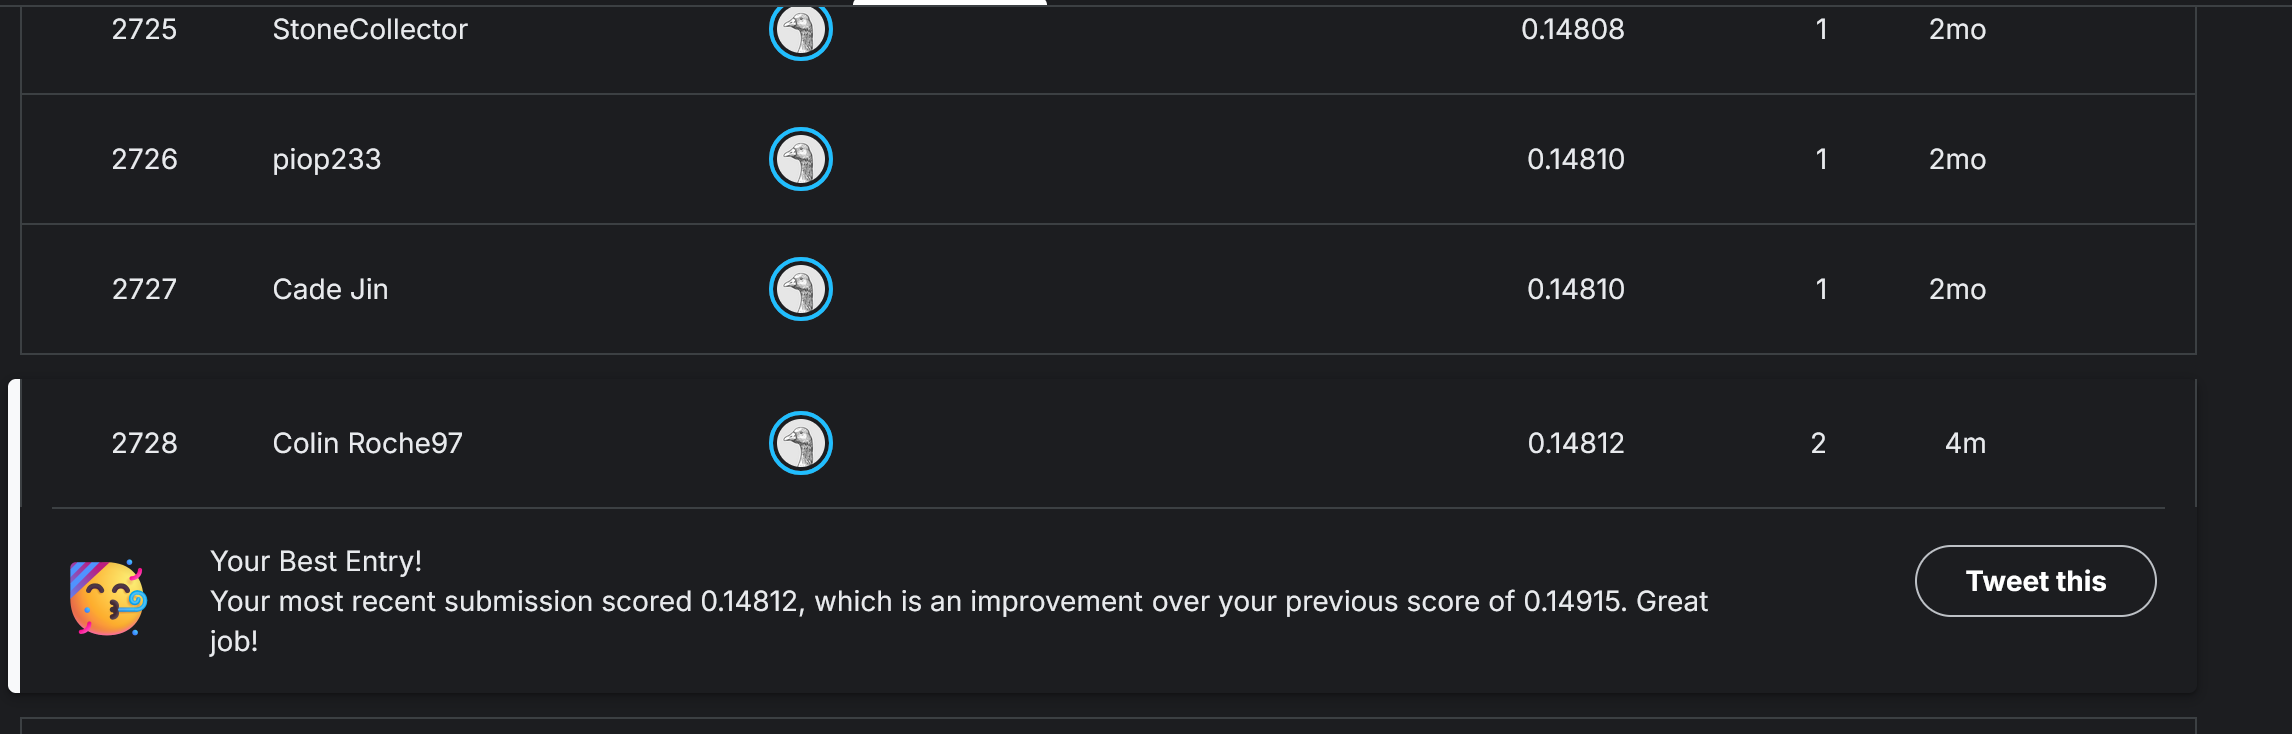

As we can see, the model achieved a public leaderboard score of 0.14812 (log-RMSE), placing 2,728th on the leaderboard (The first submission was a testing run). This is a reasonable result and one which I am happy with as a first attempt! Given the constraints of the PySpark MLlib framework, which offers a more limited set of modelling and feature engineering tools compared to the libraries typically used by top competitors such as XGBoost and LightGBM, this is a good result (and better than I personally was expecting). However, I think there are some further improvments we can make.

#8. Submission Attempt 2

For our next training, we will be making the following changes:

1. As Random forest performed the best out of our models by some distance, we will be solely focusing on this model for this attempt.

2. We are re-train our Random forest model, but this time expanding our parameter search grid to give us a greater chance to find the optimal hyperparameter set.

3. Log-transform SalePrice — since Kaggle scores on log-RMSE, training on log(SalePrice) directly and then exponentiating predictions will hopefully lead to a better score.

4. Feature Engineering: Creating composite features such as total square footage (TotalBsmtSF + 1stFlrSF + 2ndFlrSF), house age (YrSold - YearBuilt), and a remodelling flag will hopefully improve model performance by providing more directly predictive signals.


##8.1. Training Attempt 2

In [ ]:
#Perform Log Transofmation on our data to match competition evaluation
training_data = training_data.withColumn("SalePrice", log(col("SalePrice")))
testing_data = testing_data.withColumn("SalePrice", log(col("SalePrice")))

We are going to create some composite features that will hopefully provide a better predicitve insight based on values that may be more predicitve to house price.

In [ ]:
# Composite and interaction features added for submission 2
# Applied to both splits to ensure consistency

def add_engineered_features(df):
    # Total finished square footage
    df = df.withColumn("TotalSF",
        col("TotalBsmtSF") + col("1stFlrSF") + col("2ndFlrSF"))
    # Total bathrooms (half baths count as 0.5)
    df = df.withColumn("TotalBaths",
        col("FullBath") + col("HalfBath") * 0.5 +
        col("BsmtFullBath") + col("BsmtHalfBath") * 0.5)
    # Age of house when sold
    df = df.withColumn("HouseAge",
        col("YrSold") - col("YearBuilt"))
    # Years since last remodel
    df = df.withColumn("YearsSinceRemodel",
        col("YrSold") - col("YearRemodAdd"))
    # Quality x size interaction - captures that quality matters more in larger homes
    df = df.withColumn("QualityXSF",
        col("OverallQual") * col("GrLivArea"))
    return df

training_data = add_engineered_features(training_data)
testing_data = add_engineered_features(testing_data)

# Re-cache training_data after log transform and feature engineering
# The old cache is now stale - this ensures CV folds don't re-execute
# the log transform and withColumn operations on every fit
training_data.cache()
training_data.count()

print(f"New column count: {len(training_data.columns)}")

New column count: 107


We will now redo our preproccessing pipeline and rebuild our assemblers with these newly created columns. We will also slightly increase our feature threshold to account for these new features as is common in this scenario.

In [ ]:
# Rebuild numerical feature list to include engineered columns
engineered_cols = [
    "TotalSF", "TotalBaths", "HouseAge",
    "YearsSinceRemodel", "QualityXSF"
]

numerical_features_v2 = continuous_cols + discrete_cols + ordinal_encoded_cols + engineered_cols

# Rebuild assemblers with new feature list
num_assembler_v2 = VectorAssembler(
    inputCols=numerical_features_v2,
    outputCol="num_features",
    handleInvalid="skip"
)

final_assembler_v2 = VectorAssembler(
    inputCols=["num_features"] + cat_encoded_cols,
    outputCol="features",
    handleInvalid="skip"
)

encoding_stages_v2 = cat_indexers + [cat_encoder, num_assembler_v2, final_assembler_v2]

# Rebuild feature selector with higher threshold to account for new features
feature_selector_v2 = UnivariateFeatureSelector(
    featuresCol="features",
    outputCol="selected_features",
    labelCol="SalePrice",
    selectionMode="numTopFeatures"
)
feature_selector_v2.setFeatureType("continuous")
feature_selector_v2.setLabelType("continuous")
feature_selector_v2.setSelectionThreshold(55)  # slightly higher to capture new features

# Fit new preprocessing pipeline on training data
preprocessing_pipeline_v2 = Pipeline(
    stages=encoding_stages_v2 + [feature_selector_v2]
)


preprocessing_model_v2 = preprocessing_pipeline_v2.fit(training_data)
train_features_v2 = preprocessing_model_v2.transform(training_data)
test_features_v2  = preprocessing_model_v2.transform(testing_data)

# Cache new feature set
train_features_v2.cache()
train_features_v2.count()

1207

We wil now define a new random forest param grid with expanded options.

Note: I had initally hoped to give more options (larger numTrees and MaxDepth), but was running into issues with Colab's VM memory and training time was becoming to large.

In [ ]:
# Random Forest Regressor (uses pre-computed selected_features, no scaling needed)
rf2 = RandomForestRegressor(
    featuresCol="selected_features",
    labelCol="SalePrice"
)

rf2_grid = (ParamGridBuilder()
    .addGrid(rf2.numTrees, [200]) #found as best value from preivous testing
    .addGrid(rf2.maxDepth, [15]) #found as best value from previous testing
    # minInstancesPerNode: new - controls leaf size and overfitting
    .addGrid(rf2.minInstancesPerNode, [1, 2, 5])
    # featureSubsetStrategy: how many features considered at each split
    # sqrt is RF default, log2 is more aggressive, 0.5 is more conservative
    .addGrid(rf2.featureSubsetStrategy, ["sqrt", "log2", "0.5"])
    .build()
)

rf2_cv = CrossValidator(
    estimator=rf2,
    estimatorParamMaps=rf2_grid,
    evaluator=evaluator,
    numFolds=5,
    parallelism=cores,
    seed=42
)

We will now train our on our new param grid and engineered features

In [ ]:
models = {
    "Random Forest 2": rf2_cv
}

results = []
best_models = {}

for name, cv in models.items():
    print(f"\nTraining {name} with {cv.getNumFolds()}-fold CV...")
    start_time = time.time()
    cv_model = cv.fit(train_features_v2)    #v2 features
    elapsed = time.time() - start_time
    print(f"  Completed in {elapsed:.1f}s")

    best_pipeline_model = cv_model.bestModel
    best_params = cv_model.getEstimatorParamMaps()[
        cv_model.avgMetrics.index(__builtins__.min(cv_model.avgMetrics))
    ]

    print(f"\n  Best hyperparameters:")
    for param, value in best_params.items():
        print(f"    {param.name}: {value}")

    predictions = cv_model.transform(test_features_v2)    # v2 features

    rmse = evaluator.evaluate(predictions)
    r2   = evaluator_r2.evaluate(predictions)
    mae  = evaluator_mae.evaluate(predictions)
    best_cv_rmse = __builtins__.min(cv_model.avgMetrics)

    results.append((name, rmse, r2, mae, best_cv_rmse, elapsed))
    best_models[name] = cv_model

    print(f"\n  Results:")
    print(f"Best CV RMSE: {best_cv_rmse:.4f}")
    print(f"Test RMSE:    {rmse:.4f}")
    print(f"Test R²:      {r2:.4f}")
    print(f"Test MAE:     {mae:.4f}")

best = min(results, key=lambda x: x[1])
print(f"\nBest model: {best[0]} (Test RMSE: {best[1]:.4f})")


Training Random Forest 2 with 5-fold CV...
  Completed in 1748.4s

  Best hyperparameters:
    numTrees: 200
    maxDepth: 15
    minInstancesPerNode: 1
    featureSubsetStrategy: log2

  Results:
Best CV RMSE: 0.1377
Test RMSE:    0.1381
Test R²:      0.8932
Test MAE:     0.0914

Best model: Random Forest 2 (Test RMSE: 0.1381)


As our results use a different score to our original Random Forest model, it is difficult to compare them directly. We can, however, see an improvment in our R2 score from our previous model (0.89 vs. 0.97) indicating an improvement in model performance.

We will now submit our second (hopefully improved) results

We will perform our new preprocessing pipeline on our submission data, generate our predictions and finally, revert our now log predictions back to submission format using exp.

In [ ]:
# Load and prepare submission data for attempt 2
submission_data_v2 = spark.read.csv("test.csv", header=True, inferSchema=True)

# Extended cast list for test.csv
submission_cast_cols = cast_cols + [
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "GarageArea", "BsmtFullBath", "BsmtHalfBath", "GarageCars"
]

for c in submission_cast_cols:
    submission_data_v2 = submission_data_v2.withColumn(
        c, when(col(c).cast("string") == "NA", 0).otherwise(col(c)).cast("double")
    )

# Save Id
submission_ids_v2 = submission_data_v2.select("Id")
submission_data_v2 = submission_data_v2.drop("Id")

# Apply ordinal encoding
submission_data_v2 = encode_ordinal(submission_data_v2)

# Apply same feature engineering
submission_data_v2 = add_engineered_features(submission_data_v2)

# Apply v2 preprocessing pipeline
submission_data_v2 = preprocessing_model_v2.transform(submission_data_v2)

# Generate predictions
best_model_v2 = best_models["Random Forest 2"]
submission_predictions_v2 = best_model_v2.transform(submission_data_v2)

# Revert log transform for submissions
submission_predictions_v2 = submission_predictions_v2.withColumn(
    "prediction", exp(col("prediction"))
)

In [ ]:
# Join with Id and write CSV
submission_v2 = submission_ids_v2.withColumn(
    "row_id", monotonically_increasing_id()
).join(
    submission_predictions_v2.select(
        col("prediction").alias("SalePrice"),
        monotonically_increasing_id().alias("row_id")
    ),
    on="row_id"
).drop("row_id").select("Id", "SalePrice")

submission_v2.coalesce(1).write.csv("submissionV2", header=True, mode="overwrite")

part_file = glob.glob("submissionV2/part-*.csv")[0]
shutil.copy(part_file, "submissionV2.csv")

submissionV2.csv created


In [ ]:
#Optional: Download the Submission file to ensure correct formatting.
files.download("submissionV2.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!kaggle competitions submit house-prices-advanced-regression-techniques \
    -f submissionV2.csv \
    -m "Colin Roche - PFBD Assignment Submission (Attempt 2)"

100% 33.7k/33.7k [00:00<00:00, 193kB/s]
Successfully submitted to House Prices - Advanced Regression Techniques

##8.2. Submission 2 Results

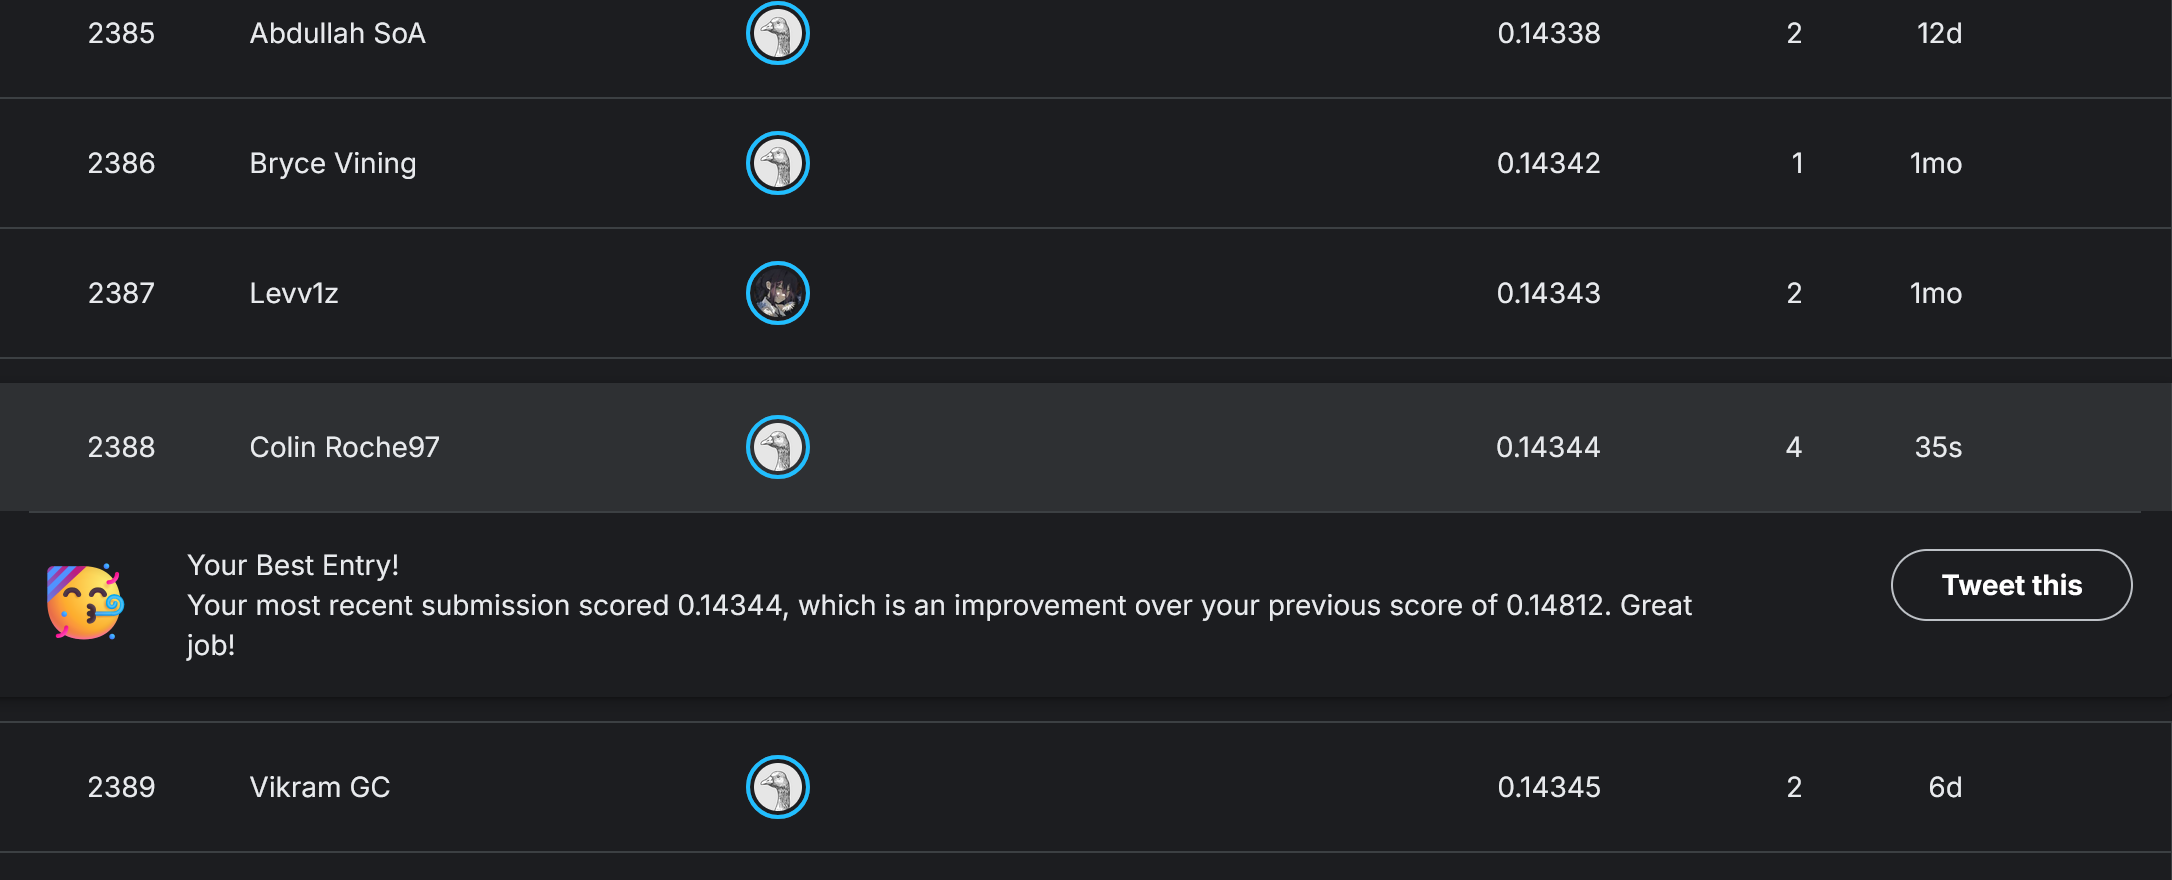

We can see from our results that our changes have led to an improvment in our score and position, falling from a socre of 0.1481 which put us in 2,777th place, to a score of 0.14344 which moves us up the leaderboard to 2,388th place! An improvment of 389 places! This clearly shows the effecitvness of feature engineering alongside greater model hyperparameter options.



#9. Areas for Future Research

While I am happy with the outcome of this submission, there are futher options that could be explored to furhter improve resutls such as:

1. Improved feature selection (maybe with more testing on optimal max feature levels)
2. Some more feature engineering
3. Testing a wider variety of models (and further investigating GBT as it is more prone to hyperparameter selection than other models).

But overall I am happy with the results and I think this shows the capabilities of Spark well!